# Customer Churn Prediction  
## Hyperparameter Tuning Using RandomizedSearchCV and GridSearchCV

**Dataset file name:** `Customer-Churn.csv`

This notebook follows the lab task style:
- Load and inspect dataset
- Preprocess data
- Build baseline Random Forest model
- Evaluate baseline model
- Apply RandomizedSearchCV
- Apply GridSearchCV
- Compare results
- Analyze overfitting / underfitting
- Try further optimization if needed

## Part 1 - Step 1: Load Dataset

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
# Check dataset shape
df.shape

(7043, 21)

In [30]:
# Check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [31]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Identify target variable
print("Target variable: Churn")
print(df["Churn"].value_counts())

Target variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Part 1 - Step 2: Data Preprocessing

**Strategy:**
- Remove `customerID` because it is only an ID.
- Convert `TotalCharges` to numeric because it may be stored as text.
- Fill missing numeric values with median.
- Fill missing categorical values with mode.
- Encode target column `Churn`.
- Apply one-hot encoding to categorical input features.
- Split the data into training and testing sets.

In [32]:
churn_data = data.copy()

churn_data = churn_data.drop("customerID", axis=1)

churn_data["TotalCharges"] = churn_data["TotalCharges"].replace(" ", np.nan)
churn_data["TotalCharges"] = churn_data["TotalCharges"].astype(float)
churn_data["TotalCharges"] = churn_data["TotalCharges"].fillna(churn_data["TotalCharges"].mean())

le = LabelEncoder()

for column in churn_data.columns:
    if churn_data[column].dtype == "object":
        churn_data[column] = le.fit_transform(churn_data[column])

churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Deliverable 1: Exploratory Analysis

In [9]:
# Class distribution
class_counts = y.value_counts()
class_counts

Churn
0    5174
1    1869
Name: count, dtype: int64

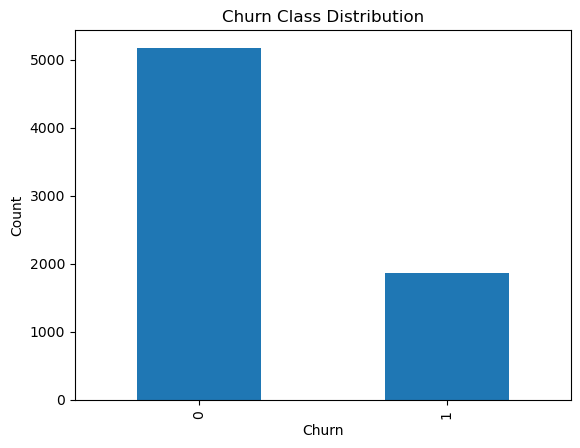

In [10]:
# Class distribution plot
class_counts.plot(kind="bar")
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [11]:
# Percentage distribution
y.value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## Part 1 - Step 3: Build Baseline Model

In [12]:
from sklearn.ensemble import RandomForestClassifier
import time

# Baseline Random Forest model
baseline_model = RandomForestClassifier(random_state=42)

# Train baseline model and record training time
start_time = time.time()
baseline_model.fit(X_train, y_train)
baseline_time = time.time() - start_time

print("Baseline model training completed.")
print("Training time:", round(baseline_time, 2), "seconds")

Baseline model training completed.
Training time: 2.23 seconds


## Part 1 - Step 4: Evaluate Baseline Model

The required metrics are:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Teacher-style evaluation function
def evaluate_preds(y_true, y_preds):
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds, zero_division=0)
    recall = recall_score(y_true, y_preds, zero_division=0)
    f1 = f1_score(y_true, y_preds, zero_division=0)

    metric_dictionary = {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    return metric_dictionary

In [14]:
# Baseline predictions
baseline_preds = baseline_model.predict(X_test)

# Baseline metrics
baseline_metrics = evaluate_preds(y_test, baseline_preds)

Accuracy: 0.7864
Precision: 0.6237
Recall: 0.4920
F1-score: 0.5501


In [15]:
# Confusion matrix for baseline model
baseline_cm = confusion_matrix(y_test, baseline_preds)
baseline_cm

array([[924, 111],
       [190, 184]])

In [16]:
# Classification report for baseline model
print(classification_report(y_test, baseline_preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



## Part 2A: RandomizedSearchCV

**Purpose:**  
RandomizedSearchCV checks random combinations of hyperparameters.  
It is faster than GridSearchCV when the search space is large.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter distribution for RandomizedSearchCV
random_grid = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Model
rf_model = RandomForestClassifier(random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=random_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Train RandomizedSearchCV
start_time = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print("RandomizedSearchCV completed.")
print("Training time:", round(random_time, 2), "seconds")

RandomizedSearchCV completed.
Training time: 49.66 seconds


In [20]:
# Best parameters from RandomizedSearchCV
random_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 10}

In [21]:
# Evaluate RandomizedSearchCV best model
random_best_model = random_search.best_estimator_
random_preds = random_best_model.predict(X_test)

random_metrics = evaluate_preds(y_test, random_preds)

Accuracy: 0.8027
Precision: 0.6655
Recall: 0.5160
F1-score: 0.5813


In [22]:
# Confusion matrix for RandomizedSearchCV model
random_cm = confusion_matrix(y_test, random_preds)
random_cm

array([[938,  97],
       [181, 193]])

In [23]:
# Classification report for RandomizedSearchCV model
print(classification_report(y_test, random_preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

          No       0.84      0.91      0.87      1035
         Yes       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Part 2B: GridSearchCV

**Purpose:**  
GridSearchCV checks all combinations of selected hyperparameters.  
It is slower but more exhaustive for a smaller search space.

In [24]:
from sklearn.model_selection import GridSearchCV

# Smaller grid for GridSearchCV to avoid very long training time
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# Model
grid_rf_model = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=grid_rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train GridSearchCV
start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print("GridSearchCV completed.")
print("Training time:", round(grid_time, 2), "seconds")

GridSearchCV completed.
Training time: 40.56 seconds


In [25]:
# Best parameters from GridSearchCV
grid_search.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

In [26]:
# Evaluate GridSearchCV best model
grid_best_model = grid_search.best_estimator_
grid_preds = grid_best_model.predict(X_test)

grid_metrics = evaluate_preds(y_test, grid_preds)

Accuracy: 0.8006
Precision: 0.6576
Recall: 0.5187
F1-score: 0.5800


In [ ]:
# Confusion matrix for GridSearchCV model
grid_cm = confusion_matrix(y_test, grid_preds)
grid_cm

In [ ]:
# Classification report for GridSearchCV model
print(classification_report(y_test, grid_preds, target_names=label_encoder.classes_))

## Part 3: Compare Results

In [ ]:
# Create performance comparison table
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time"],
    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-score"],
        round(baseline_time, 2)
    ],
    "RandomizedSearchCV": [
        random_metrics["Accuracy"],
        random_metrics["Precision"],
        random_metrics["Recall"],
        random_metrics["F1-score"],
        round(random_time, 2)
    ],
    "GridSearchCV": [
        grid_metrics["Accuracy"],
        grid_metrics["Precision"],
        grid_metrics["Recall"],
        grid_metrics["F1-score"],
        round(grid_time, 2)
    ]
})

comparison_table

## Deliverable 6: Best Hyperparameters Obtained

In [ ]:
print("Best Parameters from RandomizedSearchCV:")
print(random_search.best_params_)

print("\nBest Parameters from GridSearchCV:")
print(grid_search.best_params_)

## Deliverable 7: Final Confusion Matrix and Classification Report

Here, the better model is selected using test accuracy.

In [ ]:
# Select the best model according to test accuracy
models_accuracy = {
    "Baseline": baseline_metrics["Accuracy"],
    "RandomizedSearchCV": random_metrics["Accuracy"],
    "GridSearchCV": grid_metrics["Accuracy"]
}

best_model_name = max(models_accuracy, key=models_accuracy.get)
print("Best model based on test accuracy:", best_model_name)

if best_model_name == "Baseline":
    final_preds = baseline_preds
elif best_model_name == "RandomizedSearchCV":
    final_preds = random_preds
else:
    final_preds = grid_preds

In [ ]:
# Final confusion matrix
final_cm = confusion_matrix(y_test, final_preds)
final_cm

In [ ]:
# Final classification report
print(classification_report(y_test, final_preds, target_names=label_encoder.classes_))

## Deliverable 8: Overfitting, Underfitting, and Generalization Analysis

We compare training accuracy and testing accuracy.

In [ ]:
# Training and testing accuracy for baseline model
baseline_train_acc = baseline_model.score(X_train, y_train)
baseline_test_acc = baseline_model.score(X_test, y_test)

# Training and testing accuracy for RandomizedSearchCV best model
random_train_acc = random_best_model.score(X_train, y_train)
random_test_acc = random_best_model.score(X_test, y_test)

# Training and testing accuracy for GridSearchCV best model
grid_train_acc = grid_best_model.score(X_train, y_train)
grid_test_acc = grid_best_model.score(X_test, y_test)

overfit_table = pd.DataFrame({
    "Model": ["Baseline", "RandomizedSearchCV", "GridSearchCV"],
    "Training Accuracy": [
        round(baseline_train_acc, 4),
        round(random_train_acc, 4),
        round(grid_train_acc, 4)
    ],
    "Testing Accuracy": [
        round(baseline_test_acc, 4),
        round(random_test_acc, 4),
        round(grid_test_acc, 4)
    ],
    "Difference": [
        round(baseline_train_acc - baseline_test_acc, 4),
        round(random_train_acc - random_test_acc, 4),
        round(grid_train_acc - grid_test_acc, 4)
    ]
})

overfit_table

In [ ]:
# Simple analysis
for index, row in overfit_table.iterrows():
    model_name = row["Model"]
    train_acc = row["Training Accuracy"]
    test_acc = row["Testing Accuracy"]
    diff = row["Difference"]

    print("\nModel:", model_name)
    print("Training Accuracy:", train_acc)
    print("Testing Accuracy:", test_acc)
    print("Difference:", diff)

    if diff > 0.10:
        print("Analysis: Possible overfitting because training accuracy is much higher than testing accuracy.")
    elif train_acc < 0.70 and test_acc < 0.70:
        print("Analysis: Possible underfitting because both training and testing accuracy are low.")
    else:
        print("Analysis: Model generalization is acceptable because training and testing scores are close.")

## Part 4 / Deliverable 9: Further Optimization Attempt

If results are not satisfactory, we try a slightly expanded hyperparameter space.

**Selected additional parameters:**
- `criterion`: checks Gini and Entropy splitting.
- `class_weight`: handles class imbalance.
- `max_leaf_nodes`: controls model complexity.
- `bootstrap`: checks whether bootstrap samples are used.

**Why selected:**  
These parameters can improve performance, reduce overfitting, and help with imbalanced churn classes.

In [ ]:
# Expanded search space for further optimization
expanded_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
    "max_leaf_nodes": [None, 20, 50],
    "bootstrap": [True, False]
}

expanded_model = RandomForestClassifier(random_state=42)

expanded_search = RandomizedSearchCV(
    estimator=expanded_model,
    param_distributions=expanded_grid,
    n_iter=30,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
expanded_search.fit(X_train, y_train)
expanded_time = time.time() - start_time

print("Further optimization completed.")
print("Training time:", round(expanded_time, 2), "seconds")

In [ ]:
# Best parameters from further optimization
expanded_search.best_params_

In [ ]:
# Evaluate further optimized model
expanded_best_model = expanded_search.best_estimator_
expanded_preds = expanded_best_model.predict(X_test)

expanded_metrics = evaluate_preds(y_test, expanded_preds)

In [ ]:
# Compare previous best model with further optimized model
final_comparison = pd.DataFrame({
    "Model": ["Baseline", "RandomizedSearchCV", "GridSearchCV", "Further Optimized RandomizedSearchCV"],
    "Accuracy": [
        baseline_metrics["Accuracy"],
        random_metrics["Accuracy"],
        grid_metrics["Accuracy"],
        expanded_metrics["Accuracy"]
    ],
    "Precision": [
        baseline_metrics["Precision"],
        random_metrics["Precision"],
        grid_metrics["Precision"],
        expanded_metrics["Precision"]
    ],
    "Recall": [
        baseline_metrics["Recall"],
        random_metrics["Recall"],
        grid_metrics["Recall"],
        expanded_metrics["Recall"]
    ],
    "F1-score": [
        baseline_metrics["F1-score"],
        random_metrics["F1-score"],
        grid_metrics["F1-score"],
        expanded_metrics["F1-score"]
    ],
    "Training Time": [
        round(baseline_time, 2),
        round(random_time, 2),
        round(grid_time, 2),
        round(expanded_time, 2)
    ]
})

final_comparison

## Final Written Conclusion

The baseline Random Forest model was trained first.  
Then RandomizedSearchCV and GridSearchCV were used to tune hyperparameters.  
The models were compared using Accuracy, Precision, Recall, F1-score, and Training Time.

If tuning gives only small improvement, this is normal because:
- the dataset may already be limited,
- class imbalance may affect recall,
- preprocessing and feature engineering may be more important than only tuning.

The further optimization step used additional parameters such as `criterion`, `class_weight`, `max_leaf_nodes`, and `bootstrap`.  
These parameters were selected to improve generalization, control overfitting, and handle possible class imbalance.